In [1]:
import os

os.chdir('/data2/qingyuan/projects/zengcheng3')
import sys
sys.path

from scripts.sb3_ppo_train_fe import *

from reev_control.envs import SimpleVehicleEnv4FE
from reev_control.envs.wrappers import ActionFlatteningWrapper, InfoSumWrapper, InfoHistoryWrapper
from reev_control.custom_ppo import CustomPPO
from reev_control.common.lr_schedule import linear_schedule
from reev_control.common.callbacks import WandbCallbackWithVecNorm
from reev_control.common.feature_extractor import LSTMFeatureExtractor

env_config = {
        "config_path": "reev_control/envs/config.yaml",
        "obs_seq_len": 1800,  # in seconds, = 30 minutes
        "data_start_index": 600,
        "data_min_length": 3600,
        "step_size_in_seconds": 10,
        "file_list_file": "data/train/Mar2025_filtered_files.pkl" # pickle file with list of files to load, if None, will load all files in data_folder
    }

# env_config.update({"seed": 5})
wrapped_env = make_env(**env_config)()
env = wrapped_env.unwrapped


In [ ]:
env.observation_space

Dict('non-sequential': Box(-inf, inf, (23,), float32), 'sequential': Box(-inf, inf, (1800, 8), float32))

In [ ]:
env.action_space

Box([3. 0.], [100.   1.], (2,), float32)

10


<Axes: >

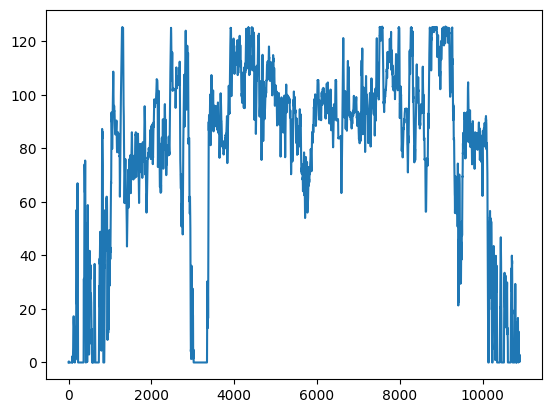

In [ ]:
print(env.step_size_in_seconds)
env.trajectory['EspVehSpd'].plot()

In [ ]:
state, step_reward, done, truncated, info = env.step([3,1])
info

{'start_speed': np.float64(50.7375),
 'end_speed': np.float64(59.117625),
 'drive_power': np.float64(36873.73966965147),
 'action.engine_stop': True,
 'action.power_request': nan,
 'torque_request': np.float64(0.0),
 'rspd_request': np.float64(0.0),
 'BcuEnyMagtSoc': 34.844561862904165,
 'BcuDchaPwrLongTiMax': 189.26912267091112,
 'BcuChrgPwrLongTiMax': 71.52204595692109,
 'FrntGerMotGenrPwr': -0.0,
 'EmsFuCns': 0.0,
 'EmsEngSpd': 0.0,
 'EmsEngTqFlywh': 0.0,
 'FrntGerSpd': 0.0,
 'FrntGerTq': -0.0,
 'BcuDchaPwrShoTiMax': 189.26912267091112,
 'BcuChrgPwrShoTiMax': 71.52204595692109,
 'done': False,
 'fc_reward': np.float64(-0.0),
 'efficiency_reward': 0.0,
 'step_soc_reward': 0.0,
 'end_soc_reward': 0.0}

### the columns of states

In [ ]:
sequential_cols = ["EspVehSpd", "EspLgtAccel", 'VcuVehAvrgEgyCnseDrivingCyc', 'VcuVehAvrgEgyCnseIn10km', 'VcuVehAvrgEgyCnseIn25km', 'DcdcCnseActPwr', 'TmsActPwr', 'VcuCalcnAccrPedlPosn']
print(len(sequential_cols))
print(state['sequential'].shape)


8
(1800, 8)


In [ ]:
non_sequential_state_vars = ['mileage_from_start', 'time_from_start', 'nav_mileage_togo', 'nav_time_togo',
    'nav_speed_q0', 'nav_speed_q10', 'nav_speed_q20', 'nav_speed_q30', 'nav_speed_q40', 'nav_speed_q50', 'nav_speed_q60', 'nav_speed_q70', 'nav_speed_q80', 'nav_speed_q90', 'nav_speed_q100',
    'VcuVehAvrgEgyCnseLongTime', 'VcuRealAccPedl']

simulated_vars = [
    'EmsEngSpd', 'EmsEngTqFlywh', 'BcuEnyMagtSoc', 'BcuDchaPwrShoTiMax',
    'BcuChrgPwrShoTiMax', 'BcuDchaPwrLongTiMax'
]

print(len(non_sequential_state_vars))
print(len(simulated_vars))
print(state['non-sequential'].shape)

17
6
(23,)


### rollout

In [2]:
# a simple strategy for generator power
import numpy as np
from scipy.interpolate import interp1d

# Speed axis (kph)
veh_spd = np.array([
    0,
    30.10000038, 40, 40.09999847,
    50, 50.09999847,
    60, 60.09999847,
    70, 70.09999847,
    80, 80.09999847,
    90, 90.09999847,
    110, 110.0999985,
    120, 120.0999985,
    130, 130.1000061,
    140
])

# ChPwr row for DrvPwrReq = 35000 W
chpwr_35000 = np.array([
    -3500, -12000, -12000, -15000, -15000,
    -18000, -18000, -21000, -21000,
    -23000, -23000, -25000, -25000,
    -28500, -30000, -33000, -33000,
    -36000, -36000, -37000, -37000
])

# Linear interpolation function
chpwr_interp = interp1d(
    veh_spd,
    -chpwr_35000,
    kind="linear",
    fill_value="extrapolate",   # allow out-of-range speeds
    bounds_error=False
)


In [5]:
print(env.reset()[1])
from reev_control.envs.simulator import Simulator
# env.simulator = Simulator(env.config['simulator_model_path'])
state, step_reward, done, truncated, info = env.step([3, 1])
info

{'BcuEnyMagtSoc': 37.92586809335977}


{'start_speed': np.float64(32.2875),
 'end_speed': np.float64(43.0734375),
 'drive_power': np.float64(156407.78023666225),
 'action.engine_stop': True,
 'action.power_request': nan,
 'torque_request': np.float64(0.0),
 'rspd_request': np.float64(0.0),
 'BcuEnyMagtSoc': 37.901572357735866,
 'BcuDchaPwrLongTiMax': 238.48166275676894,
 'BcuChrgPwrLongTiMax': 105.1433504,
 'FrntGerMotGenrPwr': -0.0,
 'EmsFuCns': 0.0,
 'EmsEngSpd': 0.0,
 'EmsEngTqFlywh': 0.0,
 'FrntGerSpd': 0.0,
 'FrntGerTq': -0.0,
 'BcuDchaPwrShoTiMax': 238.48166275676894,
 'BcuChrgPwrShoTiMax': 105.1433504,
 'done': False,
 'fc_reward': np.float64(-0.0),
 'efficiency_reward': 0,
 'step_soc_reward': 0,
 'end_soc_reward': 0}

In [6]:
env.initial_soc

37.92586809335977

In [9]:
# a simple strategy
print(env.reset()[1])
result = []
import numpy as np

action = np.array((3, 1))
done = False
while not done:
    if info['BcuEnyMagtSoc'] > 20:
        action[1] = 1  # engine stop
    elif info['BcuEnyMagtSoc'] < 15:
        action[1] = 0
    if action[1] == 0:
        action[0] = chpwr_interp(info['end_speed']) / 1000
    state, step_reward, done, truncated, info = env.step(action)
    result.append(info)

import pandas as pd

result = pd.DataFrame(result)

{'BcuEnyMagtSoc': 31.907880050295997}


In [10]:
result

,start_speed,end_speed,drive_power,action.engine_stop,action.power_request,torque_request,rspd_request,BcuEnyMagtSoc,BcuDchaPwrLongTiMax,BcuChrgPwrLongTiMax,...,EmsEngTqFlywh,FrntGerSpd,FrntGerTq,BcuDchaPwrShoTiMax,BcuChrgPwrShoTiMax,done,fc_reward,efficiency_reward,step_soc_reward,end_soc_reward
0,75.09375,75.150000,34779.851643,True,NaN,0.000000,0.00,31.821089,214.132477,87.851779,...,0.000000,0.00,-0.000000,214.132477,87.851779,False,-0.000000,0.0,0,0.000000
1,75.15000,75.148875,54984.353862,True,NaN,0.000000,0.00,31.734996,213.991811,87.865665,...,0.000000,0.00,-0.000000,213.991811,87.865665,False,-0.000000,0.0,0,0.000000
2,75.15000,70.711875,-64615.969069,True,NaN,0.000000,0.00,31.649376,213.851915,87.879475,...,0.000000,0.00,-0.000000,213.851915,87.879475,False,-0.000000,0.0,0,0.000000
3,70.70625,75.149438,44882.178370,True,NaN,0.000000,0.00,31.574445,213.729486,87.891560,...,0.000000,0.00,-0.000000,213.729486,87.891560,False,-0.000000,0.0,0,0.000000
4,75.15000,75.094875,14532.323748,True,NaN,0.000000,0.00,31.487511,213.587443,87.905582,...,0.000000,0.00,-0.000000,213.587443,87.905582,False,-0.000000,0.0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,7.59375,6.312938,-18480.154043,False,5.0,37.087379,1287.50,18.973016,195.121202,105.143350,...,37.087379,1287.50,-37.087379,195.121202,105.143350,False,-4.874768,1.0,0,0.000000
1140,6.30000,13.370625,56271.140329,False,5.0,37.087379,1287.50,19.000430,195.228582,105.143350,...,37.087379,1287.50,-37.087379,195.228582,105.143350,False,-4.864091,1.0,0,0.000000
1141,13.38750,9.859500,-35442.060013,False,7.0,48.618182,1375.00,19.029932,195.344146,105.143350,...,48.618183,1375.00,-48.618183,195.344146,105.143350,False,-6.099003,1.0,0,0.000000
1142,9.84375,1.585687,-3796.522850,False,6.0,43.042254,1331.25,19.064232,195.478505,105.143350,...,43.042255,1331.25,-43.042255,195.478505,105.143350,False,-5.504606,1.0,0,0.000000


In [15]:
result

,start_speed,end_speed,drive_power,action.engine_stop,action.power_request,torque_request,rspd_request,BcuEnyMagtSoc,BcuDchaPwrLongTiMax,BcuChrgPwrLongTiMax,...,EmsEngTqFlywh,FrntGerSpd,FrntGerTq,BcuDchaPwrShoTiMax,BcuChrgPwrShoTiMax,done,fc_reward,efficiency_reward,step_soc_reward,end_soc_reward
0,118.51875,125.097187,202811.496325,True,NaN,0.000000,0.00,17.520334,174.304902,105.14335,...,0.000000,0.00,-0.000000,174.304902,105.14335,False,-0.000000,0.0,0,0.000000
1,125.10000,123.029438,-200526.025097,True,NaN,0.000000,0.00,17.245501,173.562854,105.14335,...,0.000000,0.00,-0.000000,173.562854,105.14335,False,-0.000000,0.0,0,0.000000
2,123.01875,111.652875,178919.103951,True,NaN,0.000000,0.00,16.984163,172.857239,105.14335,...,0.000000,0.00,-0.000000,172.857239,105.14335,False,-0.000000,0.0,0,0.000000
3,111.65625,120.929063,352671.179419,True,NaN,0.000000,0.00,16.778249,174.979096,105.14335,...,0.000000,0.00,-0.000000,174.979096,105.14335,False,-0.000000,0.0,0,0.000000
4,120.93750,124.930688,135110.471149,True,NaN,0.000000,0.00,16.525553,174.271550,105.14335,...,0.000000,0.00,-0.000000,174.271550,105.14335,False,-0.000000,0.0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611,7.20000,4.053375,-2611.930185,False,5.0,37.087379,1287.50,19.422208,197.688831,105.14335,...,37.087379,1287.50,-37.087379,197.688831,105.14335,False,-4.862100,1.0,0,0.000000
612,4.05000,1.353938,-1057.654823,False,4.0,30.713568,1243.75,19.443503,197.774014,105.14335,...,30.713568,1243.75,-30.713568,197.774014,105.14335,False,-4.226417,1.0,0,0.000000
613,1.35000,0.618750,98.609133,False,3.0,23.875000,1200.00,19.457083,197.828331,105.14335,...,23.875000,1200.00,-23.875000,197.828331,105.14335,False,-3.515914,1.0,0,0.000000
614,0.61875,0.005625,-6.667912,False,3.0,23.875000,1200.00,19.471348,197.885391,105.14335,...,23.875000,1200.00,-23.875000,197.885391,105.14335,False,-3.514615,1.0,0,0.000000


In [5]:
import os
os.chdir('/data2/qingyuan/projects/zengcheng3')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
# from reev_control.envs import SimpleVehicleEnv4FE
# from reev_control.envs.wrappers import InfoHistoryWrapper
from reev_control.custom_ppo import CustomPPO
from reev_control.common.feature_extractor import LSTMFeatureExtractor

from scripts.sb3_ppo_train_fe import make_env

# === CONFIGURATION ===
run_name = "ikakm64v"
MODEL_PATH = f"train_results/models/{run_name}/model.zip"  # Update with your model path
VEC_NORM_PATH = f"train_results/models/{run_name}/vec_env.pkl"     # Path to saved VecNormalize

OUTPUT_CSV =  f"train_results/models/{run_name}/sample_inference_result.csv"
PLOT_OUTPUT = f"train_results/models/{run_name}/sample_inference_plot.png"

# Set the data you want to use (one file from your dataset)
DATA_FOLDER = "data/train/REEV07RearDrive_Mar2025"
FILE_NAME = "Mar2025_filtered_files.pkl"  # Or use a specific file: "trajectory_001.pkl"

ENV_CONFIG = {
    "config_path": "reev_control/envs/config.yaml",
    "obs_seq_len": 600,  # in seconds, = 10 minutes
    "data_start_index": 600,
    "data_min_length": 3600,
    "step_size_in_seconds": 10,
    "reward_weights": [1, 5, 0.1, 0.05],
    "file_list_file": "data/train/Mar2025_filtered_files.pkl"  # pickle file with list of files to load, if None, will load all files in data_folder
}



os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)

print("🚀 Starting single-trajectory inference...")

# === 1. Create the base environment (single instance) ===
env = DummyVecEnv([make_env(**ENV_CONFIG)])

vecnorm_env = VecNormalize.load(VEC_NORM_PATH, env)
# Note: We're loading it with `env`, which is okay — even for single env.

# === 4. Load the trained model ===
model = CustomPPO.load(
    MODEL_PATH,
    device="cuda:5"  # Or "cpu" if needed
)

# === 5. Run inference on one trajectory ===
obs = vecnorm_env.reset()  # Reset and normalize
done = False
episode_infos = []  # Hold all per-step info

print("📥 Starting episode loop...")


while not done:
    action, _ = model.predict(obs, deterministic=True)

    obs, rewards, done, info = env.step(action)

    # Extract info for this step

    episode_infos.append(info)

print(f"✅ Done. Collected {len(episode_infos)} steps.")


🚀 Starting single-trajectory inference...
📥 Starting episode loop...


/data2/qingyuan/projects/zengcheng3/reev_control/envs/wrappers.py:92: RuntimeWarning: Mean of empty slice
  info[f"{key}_avg"] = np.nanmean(values) if values.size > 0 else np.nan


✅ Done. Collected 1019 steps.


In [8]:
new_infos = []
for x in episode_infos:
    new_infos.append(x[0])

In [9]:
pd.DataFrame(new_infos)

,start_speed,end_speed,drive_power,action.engine_stop,action.power_request,torque_request,rspd_request,BcuEnyMagtSoc,BcuDchaPwrLongTiMax,BcuChrgPwrLongTiMax,...,efficiency_reward_sum,efficiency_reward_avg,step_soc_reward_sum,step_soc_reward_avg,action.engine_stop_sum,action.engine_stop_avg,action.power_request_sum,action.power_request_avg,episode,terminal_observation
0,14.11875,35.546062,41933.381044,True,NaN,0.0,0.0,30.381598,221.327610,105.14335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,35.55000,7.410375,-72490.429379,True,NaN,0.0,0.0,30.348602,221.256048,105.14335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.36875,0.000000,0.000000,True,NaN,0.0,0.0,30.334363,221.225166,105.14335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.00000,0.000000,0.000000,True,NaN,0.0,0.0,30.323928,221.202535,105.14335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.00000,0.000000,0.000000,True,NaN,0.0,0.0,30.313421,221.179748,105.14335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014,106.81875,90.743625,-214825.439452,True,NaN,0.0,0.0,0.000000,0.000000,105.14335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1015,90.73125,62.010000,-310353.528870,True,NaN,0.0,0.0,0.000000,0.000000,105.14335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1016,61.98750,25.159500,-89587.672956,True,NaN,0.0,0.0,0.000000,0.000000,105.14335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1017,25.14375,20.289937,82966.381743,True,NaN,0.0,0.0,0.000000,0.000000,105.14335,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### check model start action

In [ ]:
import os
os.chdir('/data2/qingyuan/projects/zengcheng3')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
# from reev_control.envs import SimpleVehicleEnv4FE
# from reev_control.envs.wrappers import InfoHistoryWrapper
from reev_control.custom_ppo import CustomPPO
from reev_control.common.feature_extractor import LSTMFeatureExtractor

from scripts.sb3_ppo_train_env4 import make_env

# === CONFIGURATION ===
run_name = "1cnx6npg"
MODEL_PATH = f"train_results/models/{run_name}/model.zip"  # Update with your model path
VEC_NORM_PATH = f"train_results/models/{run_name}/vec_env.pkl"     # Path to saved VecNormalize



# Set the data you want to use (one file from your dataset)
DATA_FOLDER = "data/train/REEV07RearDrive_Mar2025"
FILE_NAME = "Mar2025_filtered_files.pkl"  # Or use a specific file: "trajectory_001.pkl"

ENV_CONFIG = {
    "config_path": "reev_control/envs/config.yaml",
    "obs_seq_len": 600,  # in seconds, = 10 minutes
    "data_start_index": 600,
    "data_min_length": 3600,
    "step_size_in_seconds": 10,
    "reward_weights": [1, 5, 0.1, 0.05],
    "file_list_file": "data/train/Mar2025_filtered_files.pkl"  # pickle file with list of files to load, if None, will load all files in data_folder
}

train_config = {
    "n_envs": 8,  # number of parallel environments
    "policy_type": "MlpPolicy",
    "total_timesteps": 5_000_000,
    "n_steps": 512,  # number of steps to run per environment per rollout
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.98,
    "gae_lambda": 0.98,
    "learning_rate": 3e-4,
    "ent_coef": 0.05,
    "vf_coef": 0.25,
    "device": "cuda:5",
    "vecnorm_gamma": 0.95
}

# === 1. Create the base environment (single instance) ===
vec_env = DummyVecEnv([make_env(**ENV_CONFIG)])

vec_env = VecNormalize(vec_env,
                               training=True,
                               norm_obs=True,
                               norm_reward=False,
                            )

# === 4. Load the trained model ===
model = CustomPPO(
    policy=train_config['policy_type'],
    env=vec_env,
)

# # === 5. Run inference on one trajectory ===
# obs = vecnorm_env.reset()  # Reset and normalize
# done = False
# episode_infos = []  # Hold all per-step info

# print("📥 Starting episode loop...")


# while not done:
#     action, _ = model.predict(obs, deterministic=True)

#     obs, rewards, done, info = env.step(action)

#     # Extract info for this step

#     episode_infos.append(info)

# print(f"✅ Done. Collected {len(episode_infos)} steps.")


/data2/qingyuan/projects/zengcheng3/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run CustomPPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [18]:
model.policy.action_net.weight

Parameter containing:
tensor([[-2.7282e-03, -1.5047e-03,  3.1471e-04,  1.1137e-03, -1.1477e-03,
         -5.2712e-04, -8.5690e-04, -1.0062e-03,  4.9081e-04, -6.0788e-04,
          1.6187e-03,  4.5283e-04,  6.5334e-05, -1.5882e-03, -1.0023e-03,
         -3.7449e-04,  1.0241e-03,  5.2439e-04,  2.1343e-03, -2.1532e-03,
          8.2321e-04, -4.5618e-04, -6.2485e-04, -4.3590e-04,  9.5145e-04,
         -2.0153e-03, -2.1261e-03,  6.6364e-04,  1.3563e-03,  1.2328e-03,
          5.8216e-06, -2.3606e-04,  1.7241e-05,  7.2125e-04,  2.7718e-04,
          6.7221e-04,  1.5582e-03, -5.7678e-05,  1.3688e-03, -3.3827e-04,
          9.7596e-04, -2.2741e-04, -1.8588e-05, -2.7728e-04,  2.6371e-03,
         -2.9435e-03, -3.6492e-05,  3.6379e-06, -2.6680e-04, -1.8877e-04,
          8.4646e-04, -3.7887e-04,  2.8068e-04, -1.5086e-03, -1.3044e-04,
          9.1458e-04, -1.7273e-03,  7.9639e-04, -1.9560e-03,  2.9071e-03,
          3.6043e-04,  1.3771e-03,  7.7219e-04,  2.8841e-03]], device='cuda:0',
       req

In [19]:
model.policy.squash_output

False

In [23]:
vec_env.observation_space.sample()

array([-0.36555684, -1.207373  , -0.70969677,  0.20989671,  0.45197615,
        2.0793633 , -0.45204702,  1.7656041 ,  0.29090634,  1.157649  ,
       -0.18640992, -0.07812388,  0.7650828 ,  1.1379578 , -0.38833228,
        0.8746086 , -1.8714404 , -0.25649083, -0.88106984,  0.8152152 ,
        1.7391201 , -0.15151078,  0.08465073, -1.1671497 , -1.4155778 ,
        1.1928753 , -0.20717561, -0.55719703, -0.28750518,  0.18768066,
        2.726547  , -0.5912218 ,  1.5553031 , -0.73740226, -2.3672502 ,
       -1.867605  ,  0.56940806, -0.45848978, -0.51386625, -0.7156918 ,
        0.78953856, -0.9428229 , -1.3017553 , -0.1459227 , -0.5402674 ,
       -1.3055061 ,  0.23235065,  0.2584033 , -0.59282565, -0.35506505,
        0.32295138, -0.16322963,  0.78550935,  1.4267668 ,  0.39804453,
       -1.4055675 ,  1.0457197 ,  0.98569393, -0.19256379,  2.1138344 ,
       -1.2478364 , -1.9174709 ,  0.71600556], dtype=float32)

In [29]:
model.policy.set_training_mode(False)
obs_tensor = model.policy.obs_to_tensor(vec_env.observation_space.sample())
model.policy(obs_tensor[0])

(tensor([[0.5312]], device='cuda:0', grad_fn=<ViewBackward0>),
 tensor([[-0.8146]], device='cuda:0', grad_fn=<AddmmBackward0>),
 tensor([-1.0618], device='cuda:0', grad_fn=<SumBackward1>))

In [33]:
model.action_space

Box(0.0, 100.0, (1,), float32)